# National-Level Cost of Travel Index Calculation

This notebook loads multiple CSV files from BigQuery exports (2022-2025) and calculates the cost of a three-day weekend trip by state.

**Data Sources:**
- Accommodations: 2 nights (median per-transaction cost)
- Restaurants: 6 meals (4 breakfast/lunch at P35, 2 dinners at P65)
- Attractions: 2 days (median per-transaction cost)
- Retail: 1 day (median per-transaction cost)

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load and Concatenate Data Files

Use glob to find all CSV files in each category folder and concatenate them.

In [2]:
# Define base path
base_path = '../regional_data'

# Load Accommodations - all CSV files in accommodations folder
acc_files = glob.glob(os.path.join(base_path, 'accommodations', '*.csv'))
print(f"Found {len(acc_files)} accommodation files:")
for f in acc_files:
    print(f"  - {os.path.basename(f)}")

acc_dfs = [pd.read_csv(f) for f in acc_files]
acc = pd.concat(acc_dfs, ignore_index=True)

print(f"\nTotal accommodation records: {len(acc)}")
print(f"Date range: {acc['month_date'].min()} to {acc['month_date'].max()}")
print(f"Unique months: {acc['month_date'].nunique()}")

Found 1 accommodation files:
  - cti_regional_accommodations_2025.csv

Total accommodation records: 90
Date range: 2025-01-01 to 2025-10-01
Unique months: 10


In [3]:
# Quick check of accommodations data
acc.head()

,census_region_division,month_date,accommodation_cost,transaction_count,unique_visitors,min_cost,max_cost,q25,q75,data_quality_flag,period_start,period_end,calculation_timestamp
0,East North Central,2025-01-01,180.820007,21246,12765,59.959999,1041.670044,117.089996,301.799988,SINGLE_MONTH,2025-01-01,2025-10-31,2025-12-02 22:51:24.557749 UTC
1,East South Central,2025-01-01,167.259995,14968,8794,57.529999,1187.189941,106.570000,288.600006,SINGLE_MONTH,2025-01-01,2025-10-31,2025-12-02 22:51:24.557749 UTC
2,Middle Atlantic,2025-01-01,196.509995,10347,6377,59.660000,1473.520020,124.080002,354.149994,SINGLE_MONTH,2025-01-01,2025-10-31,2025-12-02 22:51:24.557749 UTC
3,Mountain,2025-01-01,186.500000,34855,20101,59.580002,1534.550049,112.720001,348.119995,SINGLE_MONTH,2025-01-01,2025-10-31,2025-12-02 22:51:24.557749 UTC
4,New England,2025-01-01,208.889999,3615,2443,62.220001,1282.920044,121.570000,370.049988,SINGLE_MONTH,2025-01-01,2025-10-31,2025-12-02 22:51:24.557749 UTC


In [4]:
# Load Attractions - all CSV files in attractions folder
att_files = glob.glob(os.path.join(base_path, 'attractions', '*.csv'))
print(f"Found {len(att_files)} attraction files:")
for f in att_files:
    print(f"  - {os.path.basename(f)}")

att_dfs = [pd.read_csv(f) for f in att_files]
att = pd.concat(att_dfs, ignore_index=True)

print(f"\nTotal attraction records: {len(att)}")
print(f"Date range: {att['month_date'].min()} to {att['month_date'].max()}")
print(f"Unique months: {att['month_date'].nunique()}")

Found 1 attraction files:
  - cti_regional_attractions_2025.csv

Total attraction records: 90
Date range: 2025-01-01 to 2025-10-01
Unique months: 10


In [5]:
# Load Restaurants - all CSV files in retaurants folder (note typo in folder name)
rest_files = glob.glob(os.path.join(base_path, 'restaurants', '*.csv'))
print(f"Found {len(rest_files)} restaurant files:")
for f in rest_files:
    print(f"  - {os.path.basename(f)}")

rest_dfs = [pd.read_csv(f) for f in rest_files]
rest = pd.concat(rest_dfs, ignore_index=True)

print(f"\nTotal restaurant records: {len(rest)}")
print(f"Date range: {rest['month_date'].min()} to {rest['month_date'].max()}")
print(f"Unique months: {rest['month_date'].nunique()}")

Found 1 restaurant files:
  - cti_regional_restaurants_2025.csv

Total restaurant records: 90
Date range: 2025-01-01 to 2025-10-01
Unique months: 10


In [6]:
# Load Retail - all CSV files in retail folder
ret_files = glob.glob(os.path.join(base_path, 'retail', '*.csv'))
print(f"Found {len(ret_files)} retail files:")
for f in ret_files:
    print(f"  - {os.path.basename(f)}")

ret_dfs = [pd.read_csv(f) for f in ret_files]
ret = pd.concat(ret_dfs, ignore_index=True)

print(f"\nTotal retail records: {len(ret)}")
print(f"Date range: {ret['month_date'].min()} to {ret['month_date'].max()}")
print(f"Unique months: {ret['month_date'].nunique()}")

Found 1 retail files:
  - cti_regional_retail_2025.csv

Total retail records: 90
Date range: 2025-01-01 to 2025-10-01
Unique months: 10


## 2. Data Quality Check

Verify that all datasets have consistent months and check for any data issues.

In [7]:
# Check unique months in each dataset
print("Unique months by category:")
print(f"Accommodations: {sorted(acc['month_date'].unique())}")
print(f"Attractions: {sorted(att['month_date'].unique())}")
print(f"Restaurants: {sorted(rest['month_date'].unique())}")
print(f"Retail: {sorted(ret['month_date'].unique())}")

Unique months by category:
Accommodations: ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01']
Attractions: ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01']
Restaurants: ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01']
Retail: ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01']


## 3. Merge Data Sources

Join all four datasets on state and month_date to create a unified dataset.

In [10]:
# Merge accommodations and attractions
merge_1 = pd.merge(
    acc, 
    att, 
    how='left', 
    on=[ 'month_date', 'census_region_division'], 
    suffixes=('_acc', '_att')
)

print(f"After merging accommodations + attractions: {len(merge_1)} records")

After merging accommodations + attractions: 90 records


In [11]:
# Merge restaurants and retail
merge_2 = pd.merge(
    rest, 
    ret, 
    how='left', 
    on=[ 'month_date', 'census_region_division'], 
    suffixes=('_rest', '_ret')
)

print(f"After merging restaurants + retail: {len(merge_2)} records")

After merging restaurants + retail: 90 records


In [12]:
# Final merge to combine all four data sources
final = pd.merge(
    merge_1, 
    merge_2, 
    how='left', 
    on=[ 'month_date', 'census_region_division']
)

print(f"Final merged dataset: {len(final)} records")
print(f"Date range: {final['month_date'].min()} to {final['month_date'].max()}")
print(f"Unique months: {final['month_date'].nunique()}")

Final merged dataset: 90 records
Date range: 2025-01-01 to 2025-10-01
Unique months: 10


In [13]:
# Check merged data structure
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 64 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   census_region_division              90 non-null     object 
 1   month_date                          90 non-null     object 
 2   accommodation_cost                  90 non-null     float64
 3   transaction_count_x                 90 non-null     int64  
 4   unique_visitors_acc                 90 non-null     int64  
 5   min_cost                            90 non-null     float64
 6   max_cost                            90 non-null     float64
 7   q25                                 90 non-null     float64
 8   q75                                 90 non-null     float64
 9   data_quality_flag_acc               90 non-null     object 
 10  period_start_acc                    90 non-null     object 
 11  period_end_acc                      90 non-null

## 4. Calculate Cost of Travel Index

Apply basket multiplication:
- 2 nights accommodation
- 4 breakfast/lunch meals
- 2 dinner meals
- 2 days attractions
- 1 day retail (x2 for couple)

In [15]:
# Select and rename key columns for clarity
cti = final[[
    'month_date', 
    'census_region_division',
    'accommodation_cost', 
    'attraction_cost', 
    'breakfast_lunch_cost', 
    'dinner_cost', 
    'median_meal_cost', 
    'retail_cost'
]].copy()

cti.head()

,month_date,census_region_division,accommodation_cost,attraction_cost,breakfast_lunch_cost,dinner_cost,median_meal_cost,retail_cost
0,2025-01-01,East North Central,180.820007,21.350000,17.650000,34.980000,24.57,39.610001
1,2025-01-01,East South Central,167.259995,25.980000,19.660000,37.759998,27.35,35.779999
2,2025-01-01,Middle Atlantic,196.509995,19.080000,17.500000,35.139999,24.58,39.540001
3,2025-01-01,Mountain,186.500000,28.629999,19.790001,39.389999,27.92,39.450001
4,2025-01-01,New England,208.889999,25.180000,17.590000,36.169998,24.82,45.799999


In [16]:
# Calculate total cost per trip (3-day weekend for a couple)
cti['cost_per_trip'] = (
    (cti['accommodation_cost'] * 2) +      # 2 nights
    (cti['attraction_cost'] * 2) +         # 2 days of attractions
    (cti['breakfast_lunch_cost'] * 4) +    # 4 breakfast/lunch meals
    (cti['dinner_cost'] * 2) +             # 2 dinner meals
    (cti['retail_cost'] * 2)               # 2 days of retail (couple)
)

print("Cost calculation complete!")
cti.head()

Cost calculation complete!


,month_date,census_region_division,accommodation_cost,attraction_cost,breakfast_lunch_cost,dinner_cost,median_meal_cost,retail_cost,cost_per_trip
0,2025-01-01,East North Central,180.820007,21.350000,17.650000,34.980000,24.57,39.610001,624.120014
1,2025-01-01,East South Central,167.259995,25.980000,19.660000,37.759998,27.35,35.779999,612.199982
2,2025-01-01,Middle Atlantic,196.509995,19.080000,17.500000,35.139999,24.58,39.540001,650.539989
3,2025-01-01,Mountain,186.500000,28.629999,19.790001,39.389999,27.92,39.450001,667.100002
4,2025-01-01,New England,208.889999,25.180000,17.590000,36.169998,24.82,45.799999,702.439995


## 5. Summary Statistics and Validation

In [17]:
# Show cost range by component
print("Cost per trip statistics:")
print(cti['cost_per_trip'].describe())

print("\nComponent cost ranges:")
print(f"Accommodation (2 nights): ${cti['accommodation_cost'].min():.2f} - ${cti['accommodation_cost'].max():.2f}")
print(f"Attractions (2 days): ${cti['attraction_cost'].min():.2f} - ${cti['attraction_cost'].max():.2f}")
print(f"Breakfast/Lunch (each): ${cti['breakfast_lunch_cost'].min():.2f} - ${cti['breakfast_lunch_cost'].max():.2f}")
print(f"Dinner (each): ${cti['dinner_cost'].min():.2f} - ${cti['dinner_cost'].max():.2f}")
print(f"Retail (per day): ${cti['retail_cost'].min():.2f} - ${cti['retail_cost'].max():.2f}")

Cost per trip statistics:
count     90.000000
mean     686.940443
std       43.278499
min      604.559996
25%      657.684997
50%      683.919998
75%      715.910006
max      812.419998
Name: cost_per_trip, dtype: float64

Component cost ranges:
Accommodation (2 nights): $166.87 - $254.16
Attractions (2 days): $10.48 - $31.24
Breakfast/Lunch (each): $16.46 - $22.94
Dinner (each): $33.62 - $47.89
Retail (per day): $29.20 - $49.18


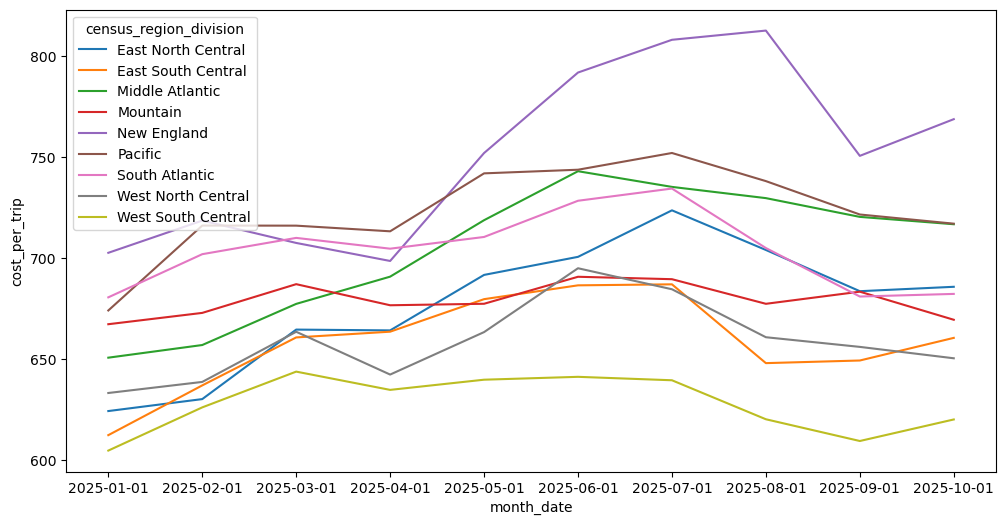

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=cti, x='month_date', y='cost_per_trip', hue='census_region_division', legend=True)
plt.savefig('CTI_Regional.png')

## 8. Export Final Dataset

In [20]:
# Export to CSV
output_filename = '../output/cti_regional_2025.csv'

# Create output directory if it doesn't exist
os.makedirs('../output', exist_ok=True)

cti.to_csv(output_filename, index=False)
print(f"\nData exported successfully to: {output_filename}")
print(f"Total records: {len(cti)}")
print(f"File size: {os.path.getsize(output_filename) / 1024:.2f} KB")


Data exported successfully to: ../output/cti_regional_2025.csv
Total records: 90
File size: 13.48 KB


In [ ]:
# Display final preview
print("\nFinal dataset preview (first 20 rows):")
cti.head(20)